# random forest

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw_dataset.csv")

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (3265, 16)


,project_id,project_type,project_scale,project_duration_years,complexity_index,initial_investment,tax_rate,risk_index,year,inflation_rate,market_growth_rate,revenue,operating_cost,capex,working_capital,cash_flow
0,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,1,0.06,0.01,25091835.95,18278559.30,5887041.96,2220759.40,-2395752.07
1,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,2,0.07,0.04,31515722.37,21472504.85,2156997.60,2711995.95,5588259.78
2,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,3,0.09,0.08,47433995.67,36251329.00,4425897.72,4174260.40,3249734.67
3,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,4,0.05,0.06,48164969.53,35344119.92,1939175.23,4229398.99,8667076.68
4,P0001,Manufacturing,Medium,9,0.68,97927899.89,0.17,0.67,5,0.06,0.12,67876067.92,49986826.23,4078154.71,5751746.19,9068670.71


In [3]:
target = "cash_flow"

features = [
    "project_type",
    "project_scale",
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

X = df[features]
y = df[target]

In [6]:
from sklearn.model_selection import train_test_split

project_ids = df["project_id"].unique().to_numpy()

train_projects, test_projects = train_test_split(
    project_ids,
    test_size=0.20,
    random_state=42
)

train_df = df[
    df["project_id"].isin(train_projects)
].copy()

test_df = df[
    df["project_id"].isin(test_projects)
].copy()

print("Training projects:", train_df["project_id"].nunique())
print("Testing projects:", test_df["project_id"].nunique())

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training projects: 400
Testing projects: 100
Training rows: 2620
Testing rows: 645


In [7]:
overlap = (
    set(train_df["project_id"])
    & set(test_df["project_id"])
)

print("Projects appearing in both sets:", len(overlap))

Projects appearing in both sets: 0


In [8]:
X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (2620, 10)
X_test: (645, 10)


In [9]:
categorical_features = [
    "project_type",
    "project_scale"
]

numerical_features = [
    "project_duration_years",
    "complexity_index",
    "initial_investment",
    "tax_rate",
    "risk_index",
    "year",
    "inflation_rate",
    "market_growth_rate"
]

In [10]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [11]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [12]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", random_forest)
    ]
)

In [13]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [14]:
y_pred = rf_pipeline.predict(X_test)

print("Number of predictions:", len(y_pred))

Number of predictions: 645


In [15]:
comparison = pd.DataFrame({
    "actual_cash_flow": y_test.values,
    "predicted_cash_flow": y_pred
})

comparison.head(10)

,actual_cash_flow,predicted_cash_flow
0,-2395752.07,-5.745598e+06
1,5588259.78,5.474647e+06
2,3249734.67,8.239091e+06
3,8667076.68,8.744756e+06
4,9068670.71,9.633059e+06
5,10906457.69,9.525307e+06
6,7209321.18,9.848437e+06
7,10192767.52,9.457571e+06
8,10402911.22,1.021717e+07
9,1625496.13,-1.445078e+06


In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print(f"MAE:  ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  ₹4,439,822.44
RMSE: ₹6,541,706.82
R²:   0.5493


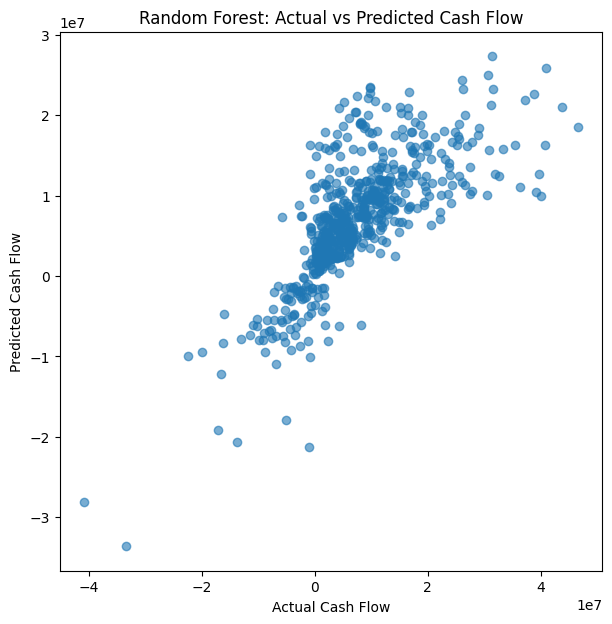

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Cash Flow")
plt.ylabel("Predicted Cash Flow")
plt.title("Random Forest: Actual vs Predicted Cash Flow")

plt.show()

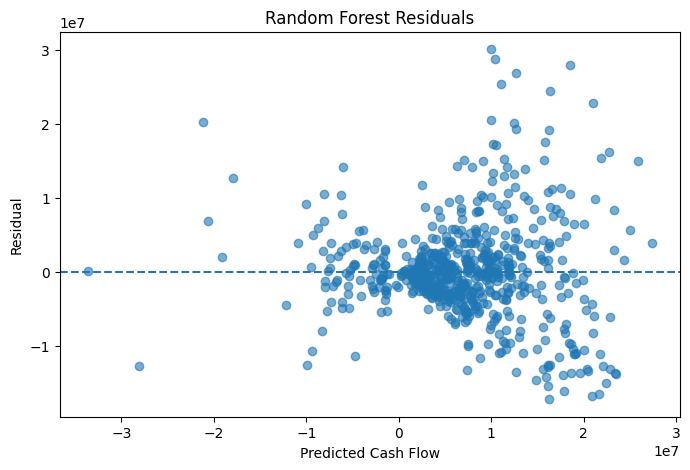

In [18]:
residuals = y_test.values - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Cash Flow")
plt.ylabel("Residual")
plt.title("Random Forest Residuals")

plt.show()

feature importance

In [19]:
model = rf_pipeline.named_steps["model"]

preprocessor_fitted = (
    rf_pipeline
    .named_steps["preprocessing"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

In [20]:
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
11,numerical__initial_investment,0.374277
14,numerical__year,0.321941
10,numerical__complexity_index,0.054518
12,numerical__tax_rate,0.049467
13,numerical__risk_index,0.042087
2,categorical__project_type_Infrastructure,0.028202
0,categorical__project_type_Energy,0.026905
16,numerical__market_growth_rate,0.023456
9,numerical__project_duration_years,0.022744
15,numerical__inflation_rate,0.017982


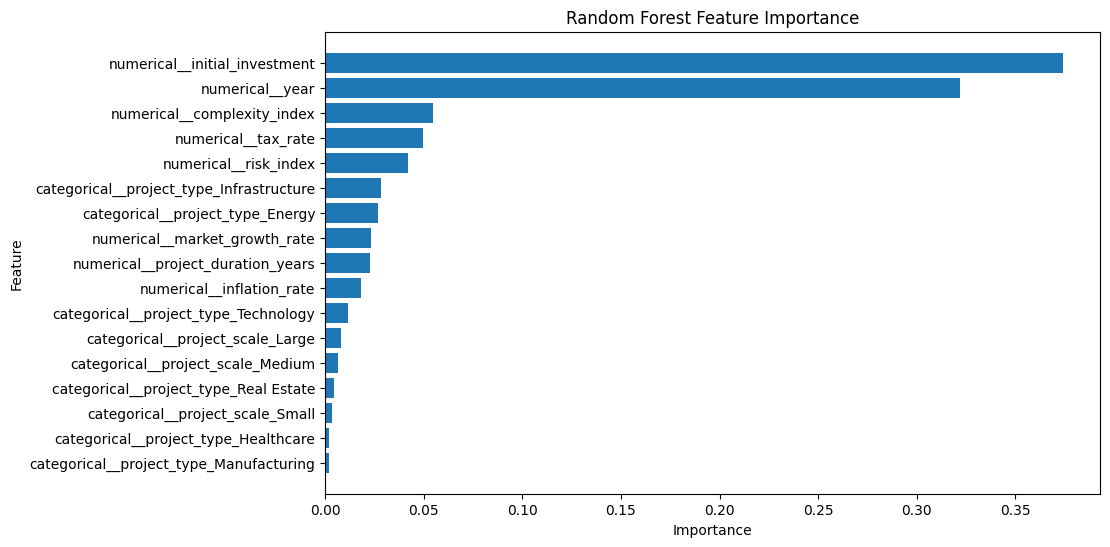

In [21]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [22]:
results = {
    "model": "Random Forest",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

results

{'model': 'Random Forest',
 'MAE': 4439822.441156485,
 'RMSE': 6541706.822842008,
 'R2': 0.5493182275160825}

In [24]:
print("Number of trees:", len(model.estimators_))
print("Number of features used by model:", model.n_features_in_)
print("Number of columns in X_train:", len(X_train.columns))

Number of trees: 300
Number of features used by model: 17
Number of columns in X_train: 10


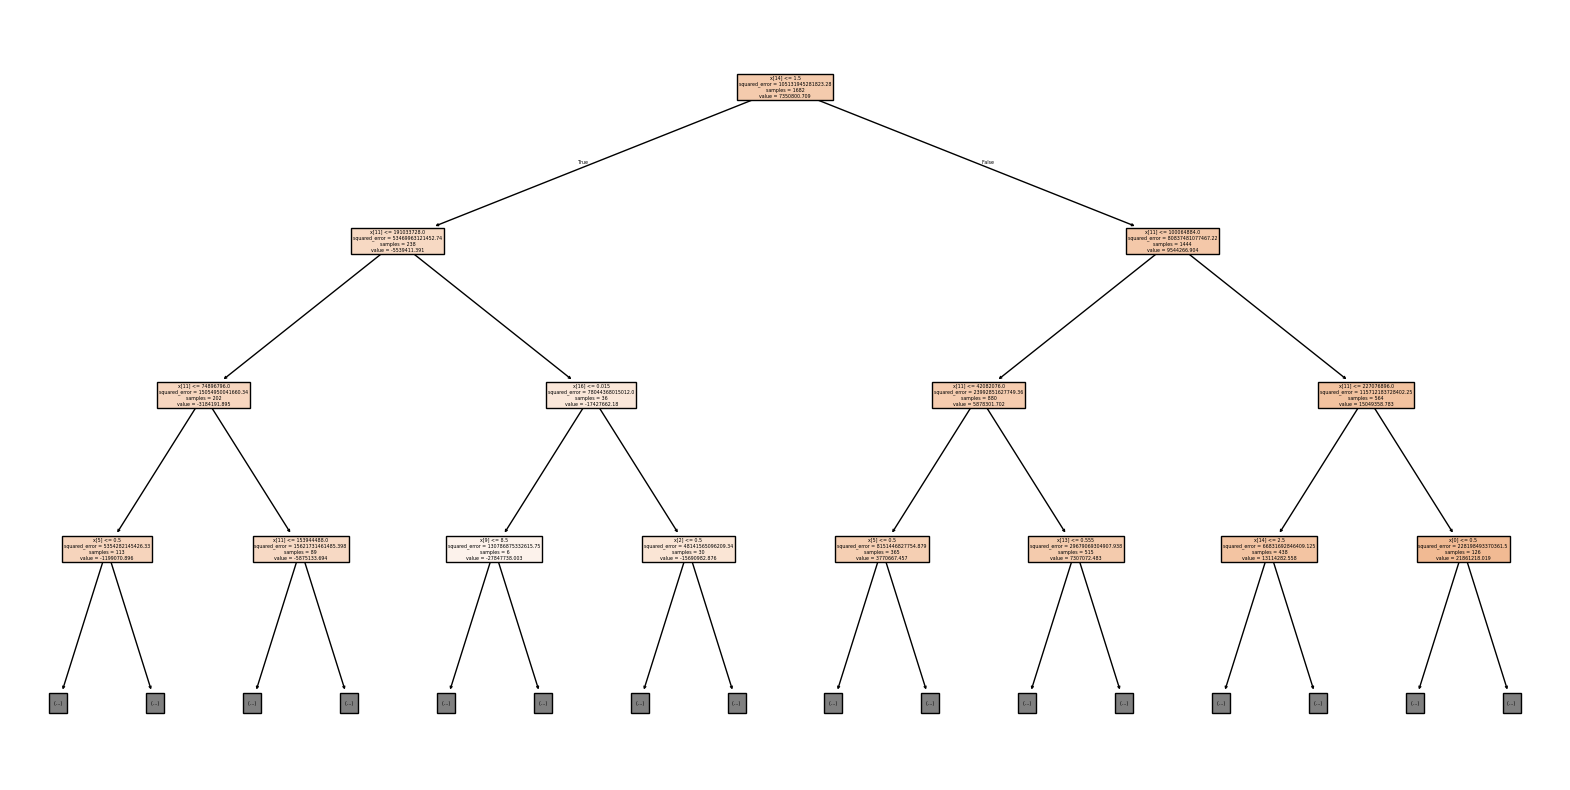

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model.estimators_[0],
    filled=True,
    max_depth=3
)

plt.show()